# Extracting Data Using Python

We can use Python or other programming languages (e.g. bash) to extract data from the LAMMPS output files. 

## Thermodynamic Data

The thermodynamic data (the total system energy and the temperature) are contained in the 'log.lammps' file. We can manually extract the data, but we can also use a Python script to read the file and automatically extract the relevant information.

Here a ``for`` loop is used to peform several checks relating to the output file. By checking the ``log`` file, we can see that the string ``"Step"`` only appears in the line before the tabulated thermodynamic data of the system. We can use this to then flag when to start recording data.

Similarly, we can add a check for the line that needs to break the loop using the string ``"Loop Time"``.

In [1]:
# using python to extract data into an easy to plot format

time_step = []
temps = []
tot_eng = []

with open("log.lammps") as file:
    # creating a variable that tells us if we should extract data from the file or not
    extract = False
    
    # looping over each line of the file to check what it contains
    for line in file:
        
        # break out of the loop if we have reached the end of the data
        if "Loop time" in line:
            break
        
        # if the line meets the conditions we extract the data from the columns, converting to a 'float' format
        if extract == True:

            time_step.append(float(line.split()[0]))
            temps.append(float(line.split()[1]))
            tot_eng.append(float(line.split()[4]))
        
        # checks for the line above the data to set the 'extract' variable to 'True'
        if "Step" in line:
            extract = True  

We can now import ``matplotlib`` and plot the energy and temperature evolutions of the system.

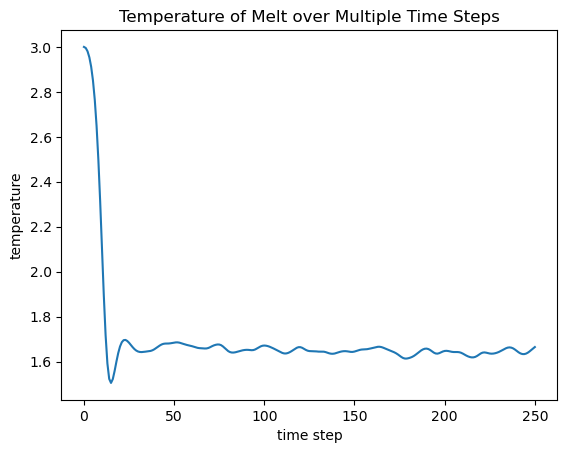

In [2]:
import matplotlib.pyplot as plt

plt.plot(time_step, temps)
plt.xlabel('time step')
plt.ylabel('temperature')
plt.title('Temperature of Melt over Multiple Time Steps')
plt.show()

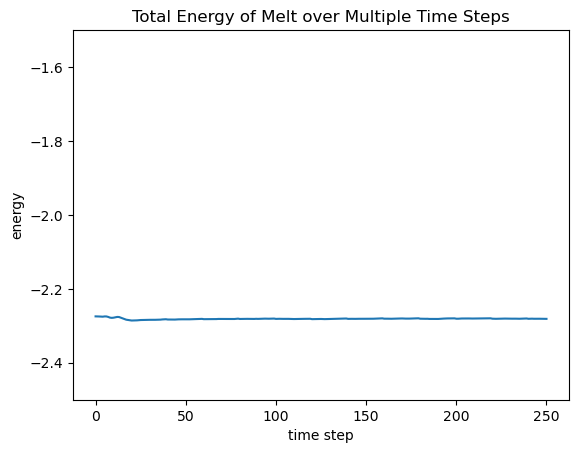

In [3]:
plt.plot(time_step, tot_eng)
plt.xlabel('time step')
plt.ylim(-2.5,-1.5)
plt.ylabel('energy')
plt.title('Total Energy of Melt over Multiple Time Steps')
plt.show()